# PPO on Pong: the policy-gradient ladder at Atari scale

The CartPole notebooks ended with a claim: PPO's clipped objective bounds the update step,
so a policy that reaches a good score stays there. That was measured on a task where an
episode is 500 steps and a run takes minutes. This notebook takes the same algorithm to
Atari — episodes of ~3,800 agent steps, observations of 4x84x84 pixels, and 15M steps per
run at ~2.5 hours each.

Two things change at this scale, and both are here:

- **Vectorised environments.** One env stepping at a time cannot feed a conv net. Eight run
  in parallel through ALE's native C++ vector env, and the rollout becomes a `(128, 8, ...)`
  tensor with per-env episode bookkeeping.
- **GAE.** On CartPole the Monte Carlo advantage was fine because rollouts roughly matched
  episodes. Here a 128-step rollout is 1/30th of an episode, and the two estimators are run
  head-to-head as the notebook's main experiment.

Everything is compared against [the DQN trained on the same
game](../../atari/pong-dqn/README.md), under the same sticky-action condition.

In [29]:
import time
import random
import torch
import ale_py
import numpy as np
import gymnasium as gym
import torch.nn as nn
import pandas as pd
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch.optim import Adam
from collections import deque
from torch.distributions import Categorical
from torch.utils.tensorboard import SummaryWriter
from gymnasium.wrappers.vector import RecordEpisodeStatistics, ClipReward

In [2]:
gym.register_envs(ale_py)
gym.__version__

'1.3.0'

## The environment

`gym.make_vec` with no `vectorization_mode` picks ALE's **native** `AtariVectorEnv`, a
multithreaded C++ implementation that does grayscale, 84x84 resize, frame stacking,
frameskip, max-pooling, no-op starts and fire-reset internally. Measured on this machine at
8 envs:

| | agent-steps/s |
|---|---|
| `sync` + Python wrappers | 1,390 |
| `async` + Python wrappers | 2,895 |
| native `vector_entry_point` | **6,508** |

Two details in the four lines below are easy to get wrong:

- **`reward_clipping=False`, then clip outside.** The native env clips in C++ by default and
  reports no episode statistics, so the true Pong score would be lost. `RecordEpisodeStatistics`
  must sit *inside* `ClipReward` — it then accumulates the raw +-1-per-point reward while the
  agent still sees clipped values. With the wrappers the other way round the agent trains
  identically and every reported score is silently wrong.
- **Do not pass `frameskip`.** The native env already skips 4. (On the *Python-wrapper* path
  the opposite holds: `gym.make(..., frameskip=1)` is required or `AtariPreprocessing` skips
  4 on top of 4. `AtariPreprocessing` raises if you forget; the native env does not.)

`ALE/Pong-v5` also defaults to `repeat_action_probability=0.25` — sticky actions. That is
kept for training, and `easy=True` turns it off for evaluation only. See the evaluation
section for why that direction and not the other.

In [17]:
gym.register_envs(ale_py)

def make_envs(num_envs=8, easy = False):
    # native AtariVectorEnv: frameskip=4, stack_num=4, maxpool, noop_max=30,
    # grayscale 84x84, fire-reset are all defaults, done in C++
    repeat_action_probability = 0.0 if easy else 0.25
    envs = gym.make_vec("ALE/Pong-v5", num_envs=num_envs, reward_clipping=False, repeat_action_probability=repeat_action_probability)
    envs = RecordEpisodeStatistics(envs)                  # raw rewards -> true Pong score
    envs = ClipReward(envs, min_reward=-1, max_reward=1)  # agent sees ±1
    return envs

In [4]:
class ActorCritic(nn.Module):
    
    def __init__(self, input_channels, action_size, seed=0):
        super().__init__()
        torch.manual_seed(seed)
        self.input_channels = input_channels
        self.action_size = action_size

        self.conv1 = nn.Conv2d(input_channels, 32, kernel_size=8, stride=4)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=4, stride=2)
        self.conv3 = nn.Conv2d(64, 64, kernel_size=3, stride=1) #7x7
        self.linear1 = nn.Linear(7*7*64, 512)
        self.pi = nn.Linear(512,action_size)
        self.v = nn.Linear(512,1)


    def forward(self,x):
        x = x / 255.0
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = F.relu(self.conv3(x))
        x = F.relu(self.linear1(x.reshape(x.shape[0], -1)))
        pi = self.pi(x)
        v = self.v(x)

        return Categorical(logits=pi), v


## Evaluation

Greedy (argmax) over 32 episodes, 8 per env across 4 envs — a fixed count *per env* rather
than the first 32 to finish, which would oversample short episodes, and short means "lost
quickly".

Two properties of this measurement are worth knowing before reading any number it produces:

- **It is blind early.** A freshly initialised network's argmax picks the same action on all
  512 real Pong states tested, while its sampled policy is essentially uniform (entropy
  1.7916 against a maximum of 1.7918). A constant action loses 21-0, so greedy evaluation
  reports exactly -21.00 +- 0.00 until the logits separate — in the first run here, for
  1.2M steps after the training score had already started moving. It is the CartPole
  training-vs-greedy gap running the other way.
- **32 episodes resolves about 1.3 points.** With the per-episode sd of ~2.3 measured on the
  sticky condition, the 95% CI is +-1.3; telling two checkpoints apart by 1 point needs ~200
  episodes. The non-sticky condition is *worse*, not better: removing sticky actions removes
  the last per-step randomness, so with an argmax policy the whole episode is decided by the
  no-op start, and the sd rises to ~6-11.

In [ ]:
def evaluate(model, device,step, num_envs = 4, easy = False):
    EPISODES_PER_ENV = 8                      # 4 envs -> 32 episodes
    envs = make_envs(num_envs=num_envs, easy=easy)
    returns = [[] for _ in range(num_envs)]
    state, _ = envs.reset(seed=0)             # seed it: evaluation should be reproducible
    with torch.no_grad():
        while min(len(r) for r in returns) < EPISODES_PER_ENV:
            state_t = torch.tensor(state).float().to(device)
            dist, _ = model(state_t)
            action = dist.probs.argmax(dim=1).cpu().numpy()
            state, reward, term, trunc, info = envs.step(action)
            if "episode" in info:
                for i, m in enumerate(info["_episode"]):
                    if m and len(returns[i]) < EPISODES_PER_ENV:
                        returns[i].append(float(info["episode"]["r"][i]))
    envs.close()

    scores = np.array([r for env_r in returns for r in env_r])
    print(f"EVAL: step {step}:  mean {scores.mean():.2f} "
        f"± {1.96*scores.std(ddof=1)/np.sqrt(scores.size):.2f} (95% CI)")

    envs.close()
    return scores.mean()            

In [ ]:
GAMMA = 0.99
lr_init = 2.5e-4
ppo_steps = 4
ppo_clip_init = .1
lam = 0.95
entropy_coef = 0.01
value_coef = 1.0
n_steps = 128
n_env = 8
# In paper they used 10M timesteps, but we will use 15M becuase of harder environment.
frames = 15_000_000 
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

## Collecting a rollout

The CartPole version of this function had one env; this one has eight, and three things
follow from that.

**`dones` records `terminated`, `prev_done` records `terminated | truncated`.** They are
deliberately different. A Pong episode cut at the frame cap is not a terminal state, so its
return must bootstrap through the cut — that is `dones`. But the vector env autoresets after
*either*, so the autoreset bookkeeping needs both. (Same distinction as
`done = not terminal_step.interrupted` in the Unity notebooks.)

**Autoreset is `NEXT_STEP`.** When an env terminates at step t, the step at t+1 ignores the
action entirely and returns the reset observation with reward 0 and `terminated=False`.
Stored naively that is a fabricated transition: a terminal observation paired with an action
that had no effect, whose value target becomes the discounted return of the *next* episode.
`valid` marks those rows so they never reach an update. They stay in the return/GAE
recursion, which is correct — the mask at the real terminal already stops the recursion, so
rows before it are unaffected. `prev_done` carries across rollouts, because a termination on
step 127 invalidates the first row of the *next* rollout.

The cost is small and was measured before fixing: 1 row in 30,720 with the trained policy,
1 in 1,200 with a random one (untrained agents lose fast, so episodes are short). It explains
none of the results below — it is fixed for correctness, not for score.

**Two advantage estimators.** `use_gae=False` is the Monte Carlo return minus V(s), i.e.
lambda = 1; `use_gae=True` is GAE with lambda = 0.95. The difference is the credit-assignment
window: the weight on a TD error l steps ahead is (gamma*lambda)^l, so the effective horizon
is 1/(1 - gamma*lambda) = 16.8 steps against gamma alone's 1/(1 - gamma) = 100. On Pong a
point takes ~35 steps, so MC advantage is dominated by *when the next point lands* — a
property of the rally, not of the action — while GAE keeps credit inside roughly half a
rally.

Note that `gae` starts at 0, so the rollout's last row gets a plain one-step TD error, and
positions near the edge are more bootstrapped than the rest: `1 - (gamma*lambda)^k` of the
weight is present k steps from the end — 5.9% at k=1, 64.8% at k=17, 98% at k=64. With
`n_steps = 128` against a horizon of 17 only the last ~13% of each rollout is affected.

In [ ]:
def collect_rollout(state, prev_done, model, envs, GAMMA, n_steps, lam, device, use_gae=False):
    """Collect exactly n_steps, spanning as many episodes as needed.
    `state` carries in from the previous rollout so no transitions are wasted.
    `prev_done` carries too, so a termination on the last step of one rollout still
    invalidates the first row of the next one.

    Autoreset: the vector env runs in NEXT_STEP mode, so the step *after* a termination
    ignores the action and returns the reset observation with reward 0 and terminated=False.
    That row is fabricated - `valid` marks it so it never reaches an update. It is only
    excluded from the *loss*, not from the return/GAE recursion: the mask at the real
    terminal already stops the recursion there, so the rows before it are unaffected."""
    states, actions, log_probs, rewards, values, dones, valids = [], [], [], [], [], [], []
    ep_returns = []
    with torch.no_grad():
        for _ in range(n_steps):
            state_t = torch.tensor(state, dtype=torch.float32).to(device)
            dist, value = model(state_t)
            action = dist.sample()

            states.append(state_t)
            actions.append(action.squeeze())
            log_probs.append(dist.log_prob(action))
            values.append(value.squeeze())
            valids.append(torch.as_tensor(~prev_done, device=device))   # False on autoreset rows

            next_state, reward, terminated, truncated, info = envs.step(action.cpu().numpy())
            if "episode" in info:
                for i, m in enumerate(info["_episode"]):
                    if m: ep_returns.append(float(info["episode"]["r"][i]))
            rewards.append(reward)
            dones.append(terminated)   # truncation is NOT terminal
            prev_done = terminated | truncated   # next row is the autoreset one

            state = next_state

        # bootstrap value for the step after the rollout's last (it cut an episode short)
        last_t = torch.tensor(state, dtype=torch.float32).to(device)
        _, next_value = model(last_t)

    values = torch.stack(values)
    rewards_t = torch.tensor(np.array(rewards), dtype=torch.float32, device=device)
    dones_t = torch.tensor(np.array(dones), dtype=torch.float32, device=device)

    if use_gae:
        advantages = torch.zeros((n_steps, n_env), device=device)
        #for the last step gae is 1 step rollout error( TD error)
        gae = torch.zeros(n_env, device=device)
        for t in reversed(range(n_steps)):
            next_val = next_value.squeeze() if t == n_steps - 1 else values[t + 1]
            mask = 1.0 - dones_t[t]
            delta = rewards_t[t] + GAMMA * next_val * mask - values[t]
            gae = delta + GAMMA * lam * mask * gae
            advantages[t] = gae
        returns = advantages + values

    else:
        returns = torch.zeros((n_steps, n_env), device=device)
        R=  next_value.squeeze()
        for t in reversed(range(n_steps)):
            mask = 1.0 - dones_t[t]
            R = rewards_t[t] + GAMMA * R * mask
            returns[t] = R
        advantages = returns - values

    return (torch.stack(states), torch.stack(actions), torch.stack(log_probs),
            returns.detach(), advantages.detach(), torch.stack(valids),
            state, prev_done, ep_returns)

## The PPO update

The clipped objective is unchanged from the CartPole notebook. What is new is the batching:
1024 transitions per rollout, shuffled into 4 minibatches of 256, 4 epochs — 16 gradient
steps per rollout rather than 4. Both learning rate and clip range are annealed linearly to
zero over the run, following the paper's `alpha` schedule.

Hyperparameters follow the PPO paper's Atari table (horizon 128, 8 actors, gamma 0.99,
lambda 0.95, clip 0.1 * alpha, lr 2.5e-4 * alpha, entropy 0.01, VF coefficient 1) with two
deviations: 4 epochs rather than 3, and no gradient-norm clipping (both arms run without it,
so the comparison is unaffected).

The budget is 15M agent steps = **60M emulator frames**, against the paper's 10M steps /
40M frames — the extra is for the sticky actions the paper predates.

In [ ]:
def run(env, seed, summary_writer, use_gae=False):
    torch.manual_seed(seed)
    np.random.seed(seed)
    model = ActorCritic(env.observation_space.shape[1], env.action_space[0].n, seed).to(device)
    optimizer = Adam(model.parameters(), lr=lr_init)

    state, _ = env.reset()
    prev_done = np.zeros(n_env, dtype=bool)   # carries across rollouts (autoreset bookkeeping)
    step_count = 0
    recent = deque(maxlen=500) 
    loss_values = []
    loss_total = []
    loss_policy = []
    loss_entropy = []
    all_ep_returns = []
    mean_values = []
    while step_count < frames:
        alpha = 1 - step_count/frames
        ppo_clip = alpha * ppo_clip_init
        optimizer.param_groups[0]["lr"] = alpha * lr_init  # anneal 2.5e-4 -> 0
        states, actions, action_probs_old, returns, advantages, valid, state, prev_done, ep_returns\
                  = collect_rollout(state, prev_done, model, env, GAMMA, n_steps, lam, device, use_gae=use_gae)
        recent.extend(ep_returns)
        all_ep_returns.extend(ep_returns)
        # drop the fabricated autoreset rows before anything else touches the batch
        valid = valid.view(-1)
        states = states.view((-1, )+ tuple(states.shape[2:]))[valid]
        actions = actions.view(-1)[valid]
        action_probs_old = action_probs_old.view(-1)[valid]
        returns = returns.view(-1)[valid]
        advantages = advantages.view(-1)[valid]
        advantages = (advantages-advantages.mean())/(advantages.std()+1e-8)

        all_loss = []
        all_value_loss = []
        all_policy_loss = []
        all_entropy = []
        all_values = []
        batch_size = states.shape[0]          # 1024 minus any autoreset rows
        minibatch_size = 256
        idx = np.arange(batch_size)
        for _ in range(ppo_steps):
            np.random.shuffle(idx)
            for start in range(0, batch_size, minibatch_size):
                mb = idx[start:start + minibatch_size]
                dists, values = model(states[mb])
                log_probs_new = dists.log_prob(actions[mb])
                ratios = torch.exp(log_probs_new - action_probs_old[mb])
                clipped = torch.clamp(ratios, 1 - ppo_clip, 1 + ppo_clip)
                policy_loss = -torch.min(ratios * advantages[mb], clipped * advantages[mb]).mean()
                value_loss = F.mse_loss(values.squeeze(-1), returns[mb])
                entropy = dists.entropy().mean()
                loss = policy_loss + value_coef * value_loss - entropy_coef * entropy
                loss.backward()
                #nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step(); optimizer.zero_grad()

                all_loss.append(loss.item())
                all_value_loss.append(value_loss.item())
                all_policy_loss.append(policy_loss.item())
                all_entropy.append(entropy.item())
                all_values.append(values.mean().item())


        step_count += n_steps*n_env
        loss_values.append(np.mean(all_value_loss))
        loss_total.append(np.mean(all_loss))
        loss_policy.append(np.mean(all_policy_loss))
        loss_entropy.append(np.mean(all_entropy))
        mean_values.append(np.mean(all_values))
        summary_writer.add_scalar('Loss/total_loss', np.mean(all_loss), step_count)
        summary_writer.add_scalar('Loss/value_loss', np.mean(all_value_loss), step_count)
        summary_writer.add_scalar('Loss/policy_loss', np.mean(all_policy_loss), step_count)
        summary_writer.add_scalar('Loss/entropy', np.mean(all_entropy), step_count)
        summary_writer.add_scalar('Value/mean', np.mean(all_values), step_count)
        if recent and step_count % (n_env * n_steps * 100) == 0:
            summary_writer.add_scalar('Train/score', np.mean(recent), step_count)
            print(f"step {step_count}:  mean {np.mean(recent):.2f}")
        
        if (step_count % (n_env * n_steps*500) == 0):
            eval_score = evaluate(model, device, step=step_count, num_envs=1)
            summary_writer.add_scalar('Eval/score', eval_score, step_count)

    env.close()
    return loss_values, loss_total, loss_policy, loss_entropy, all_ep_returns, mean_values, model


## Run 1 — Monte Carlo advantage

In [9]:
env = make_envs()
summary_writer = SummaryWriter(log_dir="ppo_pong")
loss_values, loss_total, loss_policy, loss_entropy, all_ep_returns, mean_values, model = \
    run(env, seed=0, summary_writer=summary_writer)

step 102400:  mean -20.51
step 204800:  mean -20.55
step 307200:  mean -20.53
step 409600:  mean -20.51
step 512000:  mean -20.50
EVAL: step 512000:  mean -21.00 ± 0.00 (95% CI)
step 614400:  mean -20.43
step 716800:  mean -20.30
step 819200:  mean -20.26
step 921600:  mean -20.24
step 1024000:  mean -20.23
EVAL: step 1024000:  mean -21.00 ± 0.00 (95% CI)
step 1126400:  mean -20.26
step 1228800:  mean -20.28
step 1331200:  mean -20.24
step 1433600:  mean -20.14
step 1536000:  mean -20.00
EVAL: step 1536000:  mean -21.00 ± 0.00 (95% CI)
step 1638400:  mean -19.83
step 1740800:  mean -19.62
step 1843200:  mean -19.36
step 1945600:  mean -19.13
step 2048000:  mean -18.86
EVAL: step 2048000:  mean -19.62 ± 0.73 (95% CI)
step 2150400:  mean -18.61
step 2252800:  mean -18.36
step 2355200:  mean -17.99
step 2457600:  mean -17.73
step 2560000:  mean -17.56
EVAL: step 2560000:  mean -16.25 ± 2.05 (95% CI)
step 2662400:  mean -17.32
step 2764800:  mean -17.18
step 2867200:  mean -16.87
step 2969

In [10]:
torch.save({"model": model.state_dict(), "steps": 15_000_000}, "ppo_pong_15M.pth")

In [13]:
print("Training complete. Now evaluating the model on hard environments...")
eval_score = evaluate(model, device, step=frames, num_envs=4)

Training complete. Now evaluating the model on hard environments...
EVAL: step 15000000:  mean 12.31 ± 0.81 (95% CI)


In [ ]:
print("Now evaluating the model on easy environments...")
eval_score = evaluate(model, device, step=frames, num_envs=4, easy=True)

Now evaluating the model on easy environments...
EVAL: step 15000000:  mean 11.12 ± 3.73 (95% CI)


## Run 2 — GAE (lambda = 0.95)

Same seed, same budget, same everything except the advantage estimator.

In [23]:
env = make_envs()
summary_writer = SummaryWriter(log_dir="ppo_pong_gae")
loss_values_gae, loss_total_gae, loss_policy_gae, loss_entropy_gae, all_ep_returns_gae, mean_values_gae, model_gae = \
    run(env, seed=0, summary_writer=summary_writer, use_gae=True)

step 102400:  mean -20.34
step 204800:  mean -20.44
step 307200:  mean -20.51
step 409600:  mean -20.45
step 512000:  mean -20.37
EVAL: step 512000:  mean -20.88 ± 0.24 (95% CI)
step 614400:  mean -20.35
step 716800:  mean -20.20
step 819200:  mean -20.11
step 921600:  mean -20.05
step 1024000:  mean -19.91
EVAL: step 1024000:  mean -16.50 ± 3.65 (95% CI)
step 1126400:  mean -19.58
step 1228800:  mean -19.20
step 1331200:  mean -18.83
step 1433600:  mean -18.38
step 1536000:  mean -17.96
EVAL: step 1536000:  mean -11.25 ± 2.51 (95% CI)
step 1638400:  mean -17.52
step 1740800:  mean -17.06
step 1843200:  mean -16.64
step 1945600:  mean -16.18
step 2048000:  mean -15.79
EVAL: step 2048000:  mean -11.88 ± 4.37 (95% CI)
step 2150400:  mean -15.39
step 2252800:  mean -15.08
step 2355200:  mean -14.79
step 2457600:  mean -14.50
step 2560000:  mean -14.23
EVAL: step 2560000:  mean -9.00 ± 5.11 (95% CI)
step 2662400:  mean -14.01
step 2764800:  mean -13.66
step 2867200:  mean -13.46
step 29696

In [43]:
torch.save({"model": model_gae.state_dict(), "steps": 15_000_000}, "ppo_pong_gae_15M.pth")

In [44]:
print("Training complete. Now evaluating the GAE model on hard environments...")
eval_score = evaluate(model_gae, device, step=frames, num_envs=4)

Training complete. Now evaluating the GAE model on hard environments...
EVAL: step 15000000:  mean 10.84 ± 1.48 (95% CI)


In [42]:
print("Now evaluating the GAE model on easy environments...")
eval_score = evaluate(model_gae, device, step=frames, num_envs=4, easy=True)

Now evaluating the GAE model on easy environments...
EVAL: step 15000000:  mean 16.41 ± 2.17 (95% CI)


## Results

| | training score | greedy, sticky 0.25 | greedy, no stickiness |
|---|---|---|---|
| MC advantage | +8.30 | **+12.31 +- 0.81** | +11.12 +- 3.73 |
| GAE lambda=0.95 | +9.07 | +10.84 +- 1.48 | **+16.41 +- 2.17** |

### GAE is faster early, and the gap narrows

Steps needed to first reach a given training score:

| score | MC | GAE | speedup |
|---|---|---|---|
| -20 | 1.64M | 1.02M | 1.60x |
| -15 | 3.69M | 2.36M | 1.57x |
| -10 | 5.22M | 4.71M | 1.11x |
| 0 | 9.52M | 7.99M | 1.19x |
| +8 | 14.64M | 12.80M | 1.14x |

About 1.5x while the policy is still bad, settling to ~1.15x once both are playing. The
honest claim is 15-20% fewer steps to a given score, not the 1.5x the early curve suggests.

### The two estimators produce differently-shaped policies

This is the more interesting result. Under sticky actions the two are indistinguishable
(-1.47 +- 1.69). Without stickiness, GAE is 5.3 points better (+5.29 +- 4.32, significant) —
and the MC model does not improve at all when the noise is removed (12.31 -> 11.12), while
the GAE model gains 5.6 points (10.84 -> 16.41).

So the MC policy is insensitive to action-repeat noise and the GAE policy is not. A shorter
credit-assignment window buys precision that sticky actions then take away. Both were trained
on identical data distributions, so this is a property of the estimator, not of the task.

Caveat, stated plainly: one seed per arm. At 2.5 hours per run the 10-seed protocol from the
CartPole notebooks is not available, and the non-sticky CIs are wide because that condition
has the higher variance. The per-threshold consistency of the speedup is the evidence that
*it* is not noise; the estimator-shape result would need more episodes to be safe.

### Against the DQN on the same game

| | sticky 0.25 | no stickiness |
|---|---|---|
| [DQN](../../atari/pong-dqn/README.md) (trained deterministic) | 8.85 | **21.00** |
| PPO + MC (trained sticky, 15M) | **12.31** | 11.12 |
| PPO + GAE (trained sticky, 15M) | 10.84 | 16.41 |

The DQN wins on the condition it trained under and collapses off it — 21.00 to 8.85 — which
is what its inference notebook was built to detect. PPO holds across both but is short of 21
at this budget, and its training curve was still climbing at 15M. Budget-limited, not
converged.

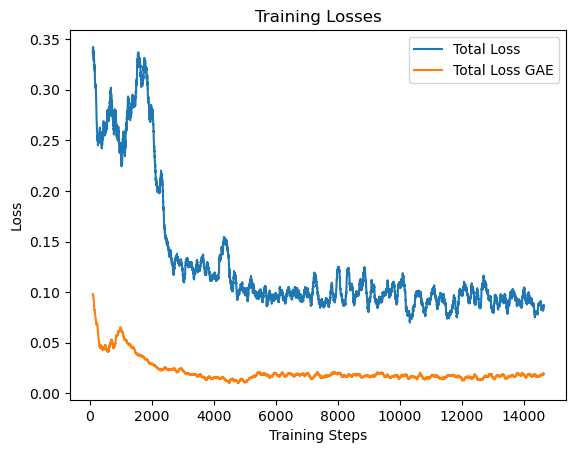

In [31]:
smooth_loss_total = pd.Series(loss_total).rolling(100).mean()
smooth_loss_total_gae = pd.Series(loss_total_gae).rolling(100).mean()
#plt.figure(figsize=(12, 8))
plt.plot(smooth_loss_total, label='Total Loss')
plt.plot(smooth_loss_total_gae, label='Total Loss GAE')
plt.xlabel('Training Steps')
plt.ylabel('Loss')
plt.title('Training Losses')
plt.legend()
plt.show()

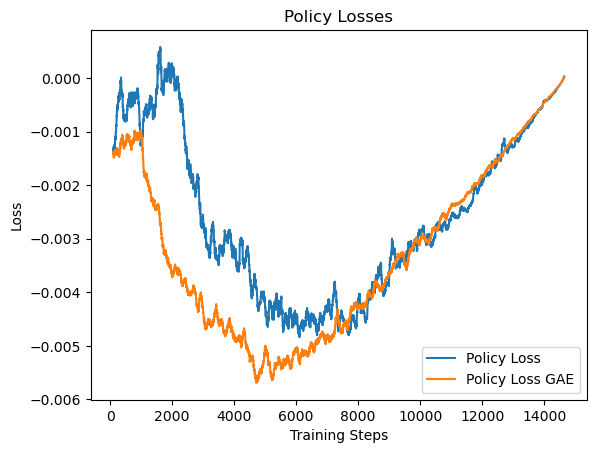

In [ ]:
smooth_loss_policy = pd.Series(loss_policy).rolling(100).mean()
smooth_loss_policy_gae = pd.Series(loss_policy_gae).rolling(100).mean()
plt.plot(smooth_loss_policy, label='Policy Loss')
plt.plot(smooth_loss_policy_gae, label='Policy Loss GAE')
plt.xlabel('Training Steps')
plt.ylabel('Loss')
plt.title('Policy Losses')
plt.legend()
plt.show()

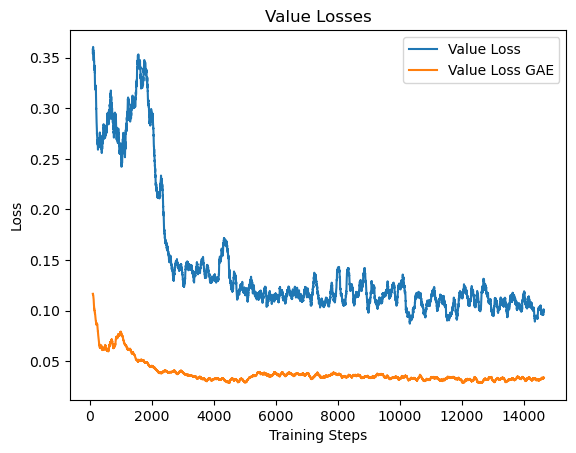

In [34]:
smooth_loss_value = pd.Series(loss_values).rolling(100).mean()
smooth_loss_value_gae = pd.Series(loss_values_gae).rolling(100).mean()
plt.plot(smooth_loss_value, label='Value Loss')
plt.plot(smooth_loss_value_gae, label='Value Loss GAE')
plt.xlabel('Training Steps')
plt.ylabel('Loss')
plt.title('Value Losses')
plt.legend()
plt.show()

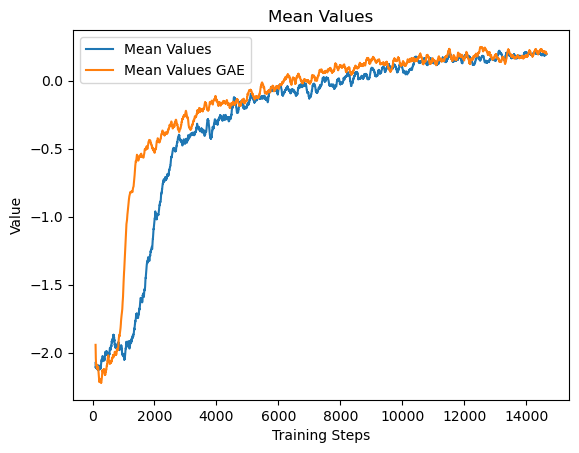

In [39]:
smooth_mean_values = pd.Series(mean_values).rolling(100).mean()
smooth_loss_value_gae = pd.Series(mean_values_gae).rolling(100).mean()
plt.plot(smooth_mean_values, label='Mean Values')
plt.plot(smooth_loss_value_gae, label='Mean Values GAE')
plt.xlabel('Training Steps')
plt.ylabel('Value')
plt.title('Mean Values')
plt.legend()
plt.show()